# Kuramoto-Sivashinsky Equation: A Chaotic PDE System

## Overview

The **Kuramoto-Sivashinsky (KS) equation** is a nonlinear partial differential equation (PDE) that exhibits spatiotemporal chaos. It was originally derived to model instabilities in flame fronts and reaction-diffusion systems, but has since become a canonical example for studying chaos in distributed systems.

## The Equation

The KS equation in one spatial dimension is:

$$\frac{\partial u}{\partial t} = -u\frac{\partial u}{\partial x} - \frac{\partial^2 u}{\partial x^2} - \frac{\partial^4 u}{\partial x^4}$$

where:
- $u(x,t)$ is the scalar field (e.g., flame front position, interface height)
- $x \in [0, L]$ is the spatial coordinate with periodic boundary conditions
- $t$ is time

## Physical Interpretation of Terms

| Term | Physical Meaning | Effect |
|------|------------------|--------|
| $-u\frac{\partial u}{\partial x}$ | **Nonlinear advection** | Steepening, wave breaking |
| $-\frac{\partial^2 u}{\partial x^2}$ | **Anti-diffusion** (unstable) | Energy injection at large scales |
| $-\frac{\partial^4 u}{\partial x^4}$ | **Hyper-diffusion** (stabilizing) | Energy dissipation at small scales |

## Chaotic Behavior

The KS equation exhibits **deterministic chaos** characterized by:

- **Sensitive dependence on initial conditions**: Small perturbations grow exponentially
- **Positive Lyapunov exponents**: Quantify the rate of divergence of nearby trajectories
- **Spatiotemporal complexity**: Irregular patterns in both space and time
- **Strange attractors**: The long-time dynamics live on a low-dimensional chaotic attractor

### Domain Size and Chaos

The domain length $L$ controls the system's behavior:

- **$L < 40$**: Stable or periodic behavior
- **$L \approx 60-100$**: Fully developed spatiotemporal chaos (most interesting regime!)
- **$L > 100$**: Extensive chaos with many active modes

## Numerical Integration

We use the **CNAB2 (Crank-Nicolson Adams-Bashforth)** pseudo-spectral method:

1. **Fourier space**: Transform $u(x,t) \to \hat{u}(k,t)$ using FFT
2. **Linear terms**: Handle diffusion/hyper-diffusion exactly via integrating factors
3. **Nonlinear term**: Compute $-u\frac{\partial u}{\partial x}$ in physical space (collocation)
4. **Time stepping**: 2nd-order semi-implicit scheme for stability and accuracy

### Advantages of this method:
- **Spectral accuracy** in space (exponential convergence for smooth solutions)
- **Stability**: Implicit treatment of stiff linear terms
- **Efficiency**: FFT operations scale as $O(N \log N)$

## Applications

### Scientific Computing
- Benchmark for testing numerical methods for chaotic PDEs
- Model problem for turbulence and pattern formation

### Machine Learning
- **Time series prediction**: Predict future states from past observations
- **Dynamics learning**: Learn operators/equations from data
- **Reduced-order modeling**: Find low-dimensional representations
- **Generative modeling**: Sample new trajectories from learned distributions

### Why KS for ML?

1. **Chaotic but deterministic**: True ground truth exists (unlike real turbulence)
2. **Computationally tractable**: Can generate large datasets efficiently
3. **Finite prediction horizon**: Tests model limitations naturally
4. **Rich spatiotemporal structure**: Complex patterns without excessive dimensionality
5. **Well-studied**: Extensive literature for comparison and validation

## Key Parameters

| Parameter | Symbol | Typical Value | Description |
|-----------|--------|---------------|-------------|
| Domain length | $L$ | 64-128 | Larger → more chaos |
| Spatial points | $N_x$ | 256-1024 | Higher → better resolution |
| Time step | $\Delta t$ | 0.0625-0.25 | Smaller → more accuracy |
| CFL condition | - | $\Delta t \sim \Delta x^4$ | Stability constraint |

## Dataset Structure

For machine learning applications, we generate multiple trajectories with different initial conditions:

- **Shape**: `(n_trajectories, n_timesteps, n_spatial_points)`
- **Typical size**: `(10, 200-500, 256-1024)`
- **Each trajectory**: Independent realization of chaotic dynamics
- **Initial conditions**: Random Fourier modes, localized perturbations, or mixed

This provides a rich dataset for training predictive models while capturing the system's ergodic properties.

## References

- Kuramoto, Y., & Tsuzuki, T. (1976). "Persistent propagation of concentration waves in dissipative media far from thermal equilibrium." *Progress of Theoretical Physics*, 55(2), 356-369.
- Sivashinsky, G. I. (1977). "Nonlinear analysis of hydrodynamic instability in laminar flames." *Acta Astronautica*, 4(11-12), 1177-1206.
- Kassam, A. K., & Trefethen, L. N. (2005). "Fourth-order time-stepping for stiff PDEs." *SIAM Journal on Scientific Computing*, 26(4), 1214-1233.

---

Integrating KS equation...
Domain: [0, 128], Nx = 512
Time steps: 1600, dt = 0.03125, T_final = 50.0
Saving every 16 steps

Generated data shape: (101, 512)
Time points: 101
Spatial points: 512

Data saved to 'ks_data.npy', 'ks_time.npy', 'ks_spatial_grid.npy'
Visualization saved to 'ks_evolution.png'


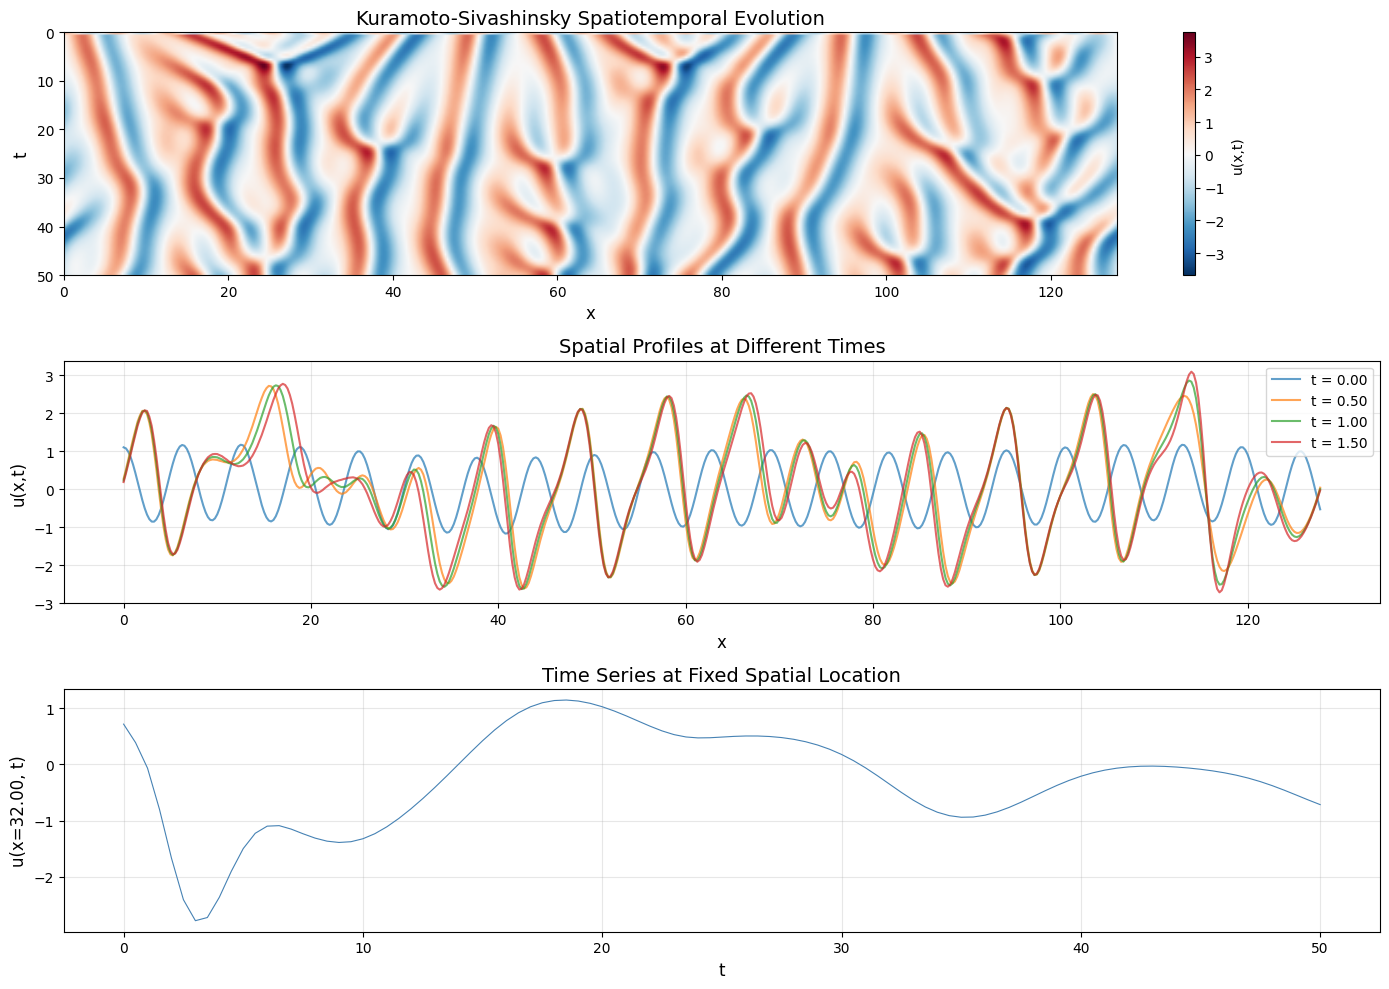


=== Data Statistics ===
  Mean: 0.031998
  Std:  1.266381
  Min:  -3.670546
  Max:  3.746190

=== For ML Time Series Prediction ===
Data shape: (101, 512) (time steps, spatial points)
Time resolution: dt_save = 0.5000
Spatial resolution: dx = 0.250000

Suggested usage:
  - Sliding window for prediction: U[i:i+history, :] -> U[i+history, :]
  - Typical history: 5-20 time steps
  - Each row is a spatial snapshot (1D field)
  - Can predict spatially: U[i, j:j+k] -> U[i, j+k+h]

=== Energy Analysis ===
Initial energy: 0.509746
Final energy: 1.736995
Energy change: 240.76%

Energy plot saved to 'ks_energy.png'


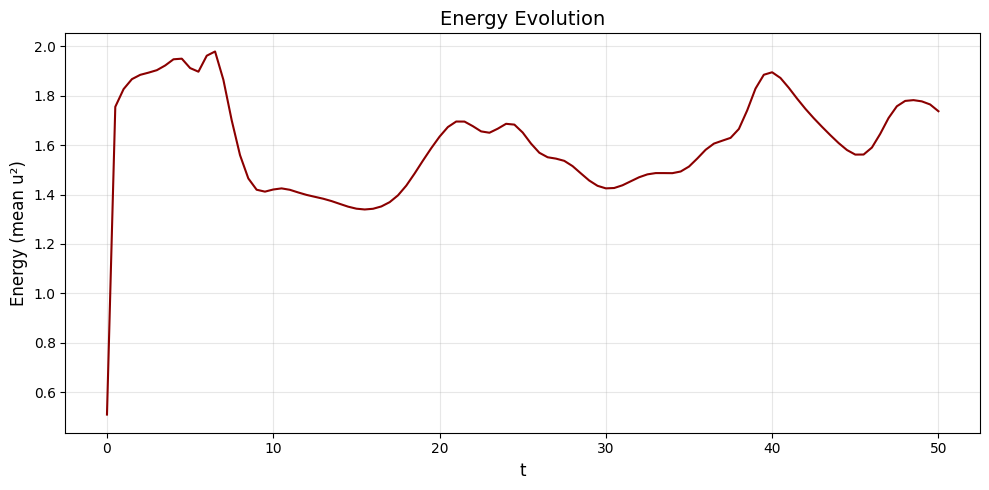

Integrating KS equation...
Domain: [0, 128], Nx = 512
Time steps: 1600, dt = 0.03125, T_final = 50.0
Saving every 20 steps

Generated data shape: (81, 512)
Time points: 81
Spatial points: 512

Data saved to 'ks_data.npy', 'ks_time.npy', 'ks_spatial_grid.npy'
Visualization saved to 'ks_evolution.png'


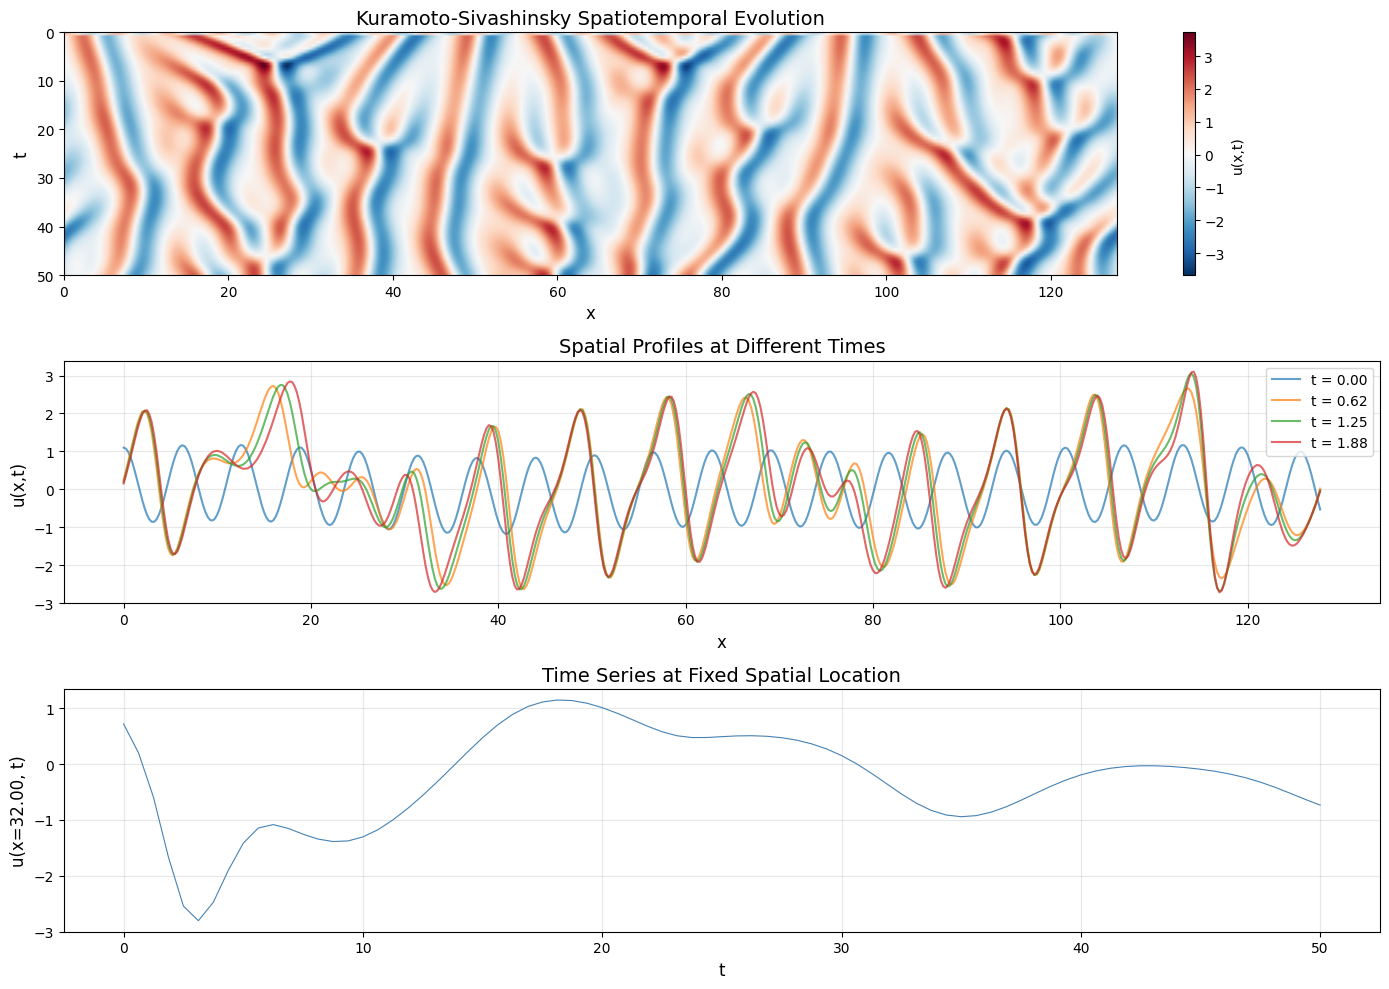


=== Data Statistics ===
  Mean: 0.031998
  Std:  1.265297
  Min:  -3.670546
  Max:  3.722850

=== For ML Time Series Prediction ===
Data shape: (81, 512) (time steps, spatial points)
Time resolution: dt_save = 0.6250
Spatial resolution: dx = 0.250000

Suggested usage:
  - Sliding window for prediction: U[i:i+history, :] -> U[i+history, :]
  - Typical history: 5-20 time steps
  - Each row is a spatial snapshot (1D field)
  - Can predict spatially: U[i, j:j+k] -> U[i, j+k+h]

=== Energy Analysis ===
Initial energy: 0.509746
Final energy: 1.727274
Energy change: 238.85%

Energy plot saved to 'ks_energy.png'


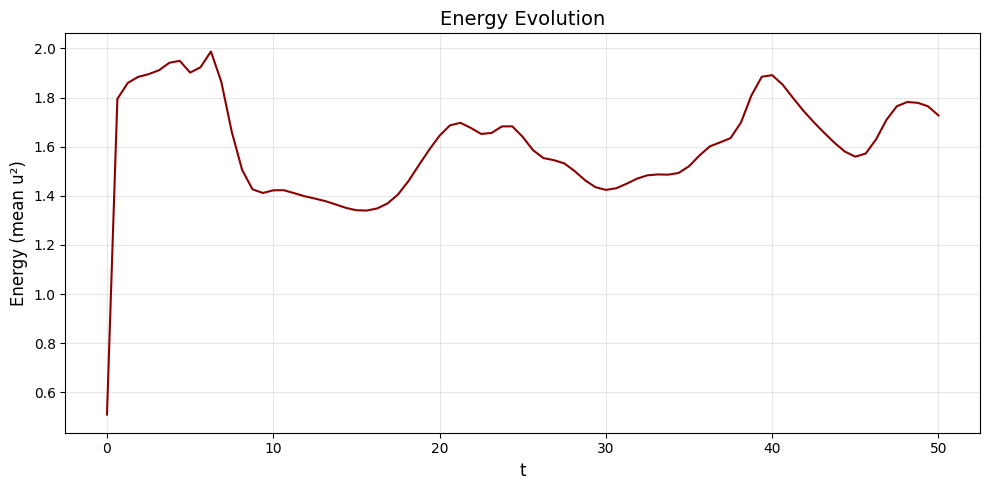

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

def ks_integrate_naive(u, Lx, dt, Nt, nplot, Nspin_up=500):
    """
    Integrate Kuramoto-Sivashinsky equation using CNAB2 (Crank-Nicolson Adam-Bashforth)
    
    Parameters:
    -----------
    u : array
        Initial condition
    Lx : float
        Domain length
    dt : float
        Time step
    Nt : int
        Total number of time steps
    nplot : int
        Save every nplot time steps
        
    Returns:
    --------
    U : array of shape (Nplot, Nx)
        Saved time series data
    x : array
        Spatial grid
    t : array
        Time points where data was saved
    """
    Nx = len(u)  # number of gridpoints
    
    # Integer wavenumbers: exp(2*pi*i*kx*x/L)
    kx = np.concatenate([np.arange(0, Nx//2), 
                         np.array([0]), 
                         np.arange(-Nx//2+1, 0)])
    
    # Real wavenumbers: exp(i*alpha*x)
    alpha = 2*np.pi*kx/Lx
    
    # Operators in Fourier space
    D = 1j*alpha                    # D = d/dx operator
    L = alpha**2 - alpha**4         # linear operator -D^2 - D^4
    G = -0.5*D                      # -1/2 D operator
    
    Nplot = int(np.round(Nt/nplot)) + 1  # total number of saved time steps
    
    # Spatial and temporal grids
    x = np.arange(Nx)*Lx/Nx
    t = np.arange(Nplot)*dt*nplot
    U = np.zeros((Nplot, Nx))
    
    # Convenience variables for CNAB2
    dt2 = dt/2
    dt32 = 3*dt/2
    A = np.ones(Nx) + dt2*L
    B = (np.ones(Nx) - dt2*L)**(-1)
    
    # -1/2 d/dx(u^2) = -u u_x, collocation calculation
    Nn = G * fft(u*u)
    Nn1 = Nn.copy()
    
    U[0, :] = u  # save initial value u to matrix U
    np_counter = 1  # counter for saved data
    
    # Transform data to spectral coefficients
    u = fft(u)
     # number of initial steps to skip for spin-up
    # Timestepping loop
    for n in range(Nt+Nspin_up):
        Nn1 = Nn.copy()                           # shift N^{n-1} <- N^n
        Nn = G * fft(np.real(ifft(u))**2)        # compute N^n = -u u_x
        
        u = B * (A * u + dt32*Nn - dt2*Nn1)      # CNAB2 formula
        
        if (n+1) % nplot == 0 and n > Nspin_up:
            U[np_counter, :] = np.real(ifft(u))
            np_counter += 1
    
    return U, x, t


# Example usage matching the Julia code
if __name__ == "__main__":
    # Parameters
    Lx = 128
    Nx = 512
    dt = 1/32
    Nt = 1600
    Nspin_up = 500  # number of initial steps to skip for spin-up

    for nplot in [16, 20]:
        pass  # Just to define nplot for later use    
        # Initial condition
        x = Lx * np.arange(Nx) / Nx
        u = np.cos(x) + 0.1*np.cos(x/16)*(1 + 2*np.sin(x/16))
        
        # Integrate
        print(f"Integrating KS equation...")
        print(f"Domain: [0, {Lx}], Nx = {Nx}")
        print(f"Time steps: {Nt}, dt = {dt}, T_final = {Nt*dt}")
        print(f"Saving every {nplot} steps")
        
        U, x, t = ks_integrate_naive(u, Lx, dt, Nt, nplot,Nspin_up)
        
        print(f"\nGenerated data shape: {U.shape}")
        print(f"Time points: {len(t)}")
        print(f"Spatial points: {Nx}")
        
        # Save data
        np.save('ks_data.npy', U)
        np.save('ks_time.npy', t)
        np.save('ks_spatial_grid.npy', x)
        print("\nData saved to 'ks_data.npy', 'ks_time.npy', 'ks_spatial_grid.npy'")
        
        # Visualization
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))
        
        # Spacetime plot
        im = axes[0].imshow(U, aspect='auto', extent=[0, Lx, t[-1], t[0]], 
                            cmap='RdBu_r', interpolation='bilinear')
        axes[0].set_xlabel('x', fontsize=12)
        axes[0].set_ylabel('t', fontsize=12)
        axes[0].set_title('Kuramoto-Sivashinsky Spatiotemporal Evolution', fontsize=14)
        plt.colorbar(im, ax=axes[0], label='u(x,t)')
        
        # Snapshots at different times
        time_indices = [0, len(t)//3, 2*len(t)//3, -1]
        time_indices = [0,1,2,3]  # first few saved times

        for idx in time_indices:
            axes[1].plot(x, U[idx, :], label=f't = {t[idx]:.2f}', alpha=0.7, linewidth=1.5)
        axes[1].set_xlabel('x', fontsize=12)
        axes[1].set_ylabel('u(x,t)', fontsize=12)
        axes[1].set_title('Spatial Profiles at Different Times', fontsize=14)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Time series at a fixed spatial location
        x_idx = Nx // 4
        axes[2].plot(t, U[:, x_idx], linewidth=0.8, color='steelblue')
        axes[2].set_xlabel('t', fontsize=12)
        axes[2].set_ylabel(f'u(x={x[x_idx]:.2f}, t)', fontsize=12)
        axes[2].set_title('Time Series at Fixed Spatial Location', fontsize=14)
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('ks_evolution.png', dpi=150, bbox_inches='tight')
        print("Visualization saved to 'ks_evolution.png'")
        plt.show()
        
        # Data statistics
        print(f"\n=== Data Statistics ===")
        print(f"  Mean: {U.mean():.6f}")
        print(f"  Std:  {U.std():.6f}")
        print(f"  Min:  {U.min():.6f}")
        print(f"  Max:  {U.max():.6f}")
        
        # Additional analysis
        print(f"\n=== For ML Time Series Prediction ===")
        print(f"Data shape: {U.shape} (time steps, spatial points)")
        print(f"Time resolution: dt_save = {dt*nplot:.4f}")
        print(f"Spatial resolution: dx = {Lx/Nx:.6f}")
        print(f"\nSuggested usage:")
        print(f"  - Sliding window for prediction: U[i:i+history, :] -> U[i+history, :]")
        print(f"  - Typical history: 5-20 time steps")
        print(f"  - Each row is a spatial snapshot (1D field)")
        print(f"  - Can predict spatially: U[i, j:j+k] -> U[i, j+k+h]")
        
        # Check energy conservation (should decay slowly for KS)
        energy = np.mean(U**2, axis=1)
        print(f"\n=== Energy Analysis ===")
        print(f"Initial energy: {energy[0]:.6f}")
        print(f"Final energy: {energy[-1]:.6f}")
        print(f"Energy change: {(energy[-1]-energy[0])/energy[0]*100:.2f}%")
        
        # Plot energy evolution
        fig2, ax = plt.subplots(figsize=(10, 5))
        ax.plot(t, energy, linewidth=1.5, color='darkred')
        ax.set_xlabel('t', fontsize=12)
        ax.set_ylabel('Energy (mean u²)', fontsize=12)
        ax.set_title('Energy Evolution', fontsize=14)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('ks_energy.png', dpi=150, bbox_inches='tight')
        print("\nEnergy plot saved to 'ks_energy.png'")
        plt.show()


# Function to generate multiple trajectories for ML training
def generate_multiple_trajectories(n_trajectories=5, **kwargs):
    """
    Generate multiple KS trajectories with different initial conditions
    
    Parameters:
    -----------
    n_trajectories : int
        Number of different trajectories to generate
    **kwargs : dict
        Parameters to pass to ks_integrate_naive (Lx, dt, Nt, nplot)
        
    Returns:
    --------
    trajectories : list of arrays
        List of trajectory arrays, each of shape (Nplot, Nx)
    """
    Lx = kwargs.get('Lx', 128)
    Nx = kwargs.get('Nx', 1024)
    dt = kwargs.get('dt', 1/16)
    Nt = kwargs.get('Nt', 1600)
    nplot = kwargs.get('nplot', 8)
    Nspin_up = kwargs.get('Nspin_up', 300)
    
    trajectories = []
    x = Lx * np.arange(Nx) / Nx
    
    print(f"Generating {n_trajectories} trajectories...")
    for i in range(n_trajectories):
        # Generate random initial condition
        np.random.seed(i)
        n_modes = 10
        u0 = np.zeros(Nx)
        for k in range(1, n_modes+1):
            phase1 = np.random.rand() * 2 * np.pi
            phase2 = np.random.rand() * 2 * np.pi
            amp = 1.0 / k
            u0 += amp * np.cos(2*np.pi*k*x/Lx + phase1)
            u0 += amp * np.sin(2*np.pi*k*x/Lx + phase2)
        
        U, _, _ = ks_integrate_naive(u0, Lx, dt, Nt, nplot, Nspin_up)
        trajectories.append(U)
        print(f"  Trajectory {i+1}/{n_trajectories} complete, shape: {U.shape}")
    
    return trajectories, x,  np.arange(nplot) * dt * nplot

## Visualization of the Flow Field

### Spacetime Plots

Each spacetime plot shows the **complete evolution of the flow field** $u(x,t)$ over the time interval displayed on the y-axis:

- **Horizontal axis (x)**: Spatial coordinate across the domain $[0, L]$
- **Vertical axis (t)**: Time, flowing from top (initial) to bottom (final)
- **Color**: Amplitude of the flow field $u(x,t)$ at each point

These plots provide a **global view of the spatiotemporal dynamics**, revealing:
- Wave propagation and interactions
- Pattern formation and destruction
- Characteristic length and time scales
- Overall chaotic behavior

### Spatial Snapshot Plots

Each snapshot plot shows the **instantaneous flow field** $u(x, t_{\text{fixed}})$ at a specific moment in time:

- **Horizontal axis (x)**: Spatial coordinate
- **Vertical axis**: Flow field amplitude $u$
- Each curve represents the spatial structure at one time point

These plots reveal:
- Instantaneous spatial patterns
- Typical length scales (wavelengths)
- Amplitude variations
- How the spatial structure evolves over time

### Time Series Plots

Each time series plot shows the **temporal evolution of the flow field** at a fixed spatial location $u(x_{\text{fixed}}, t)$:

- **Horizontal axis (t)**: Time
- **Vertical axis**: Flow field amplitude $u$
- Each curve represents the temporal dynamics at one spatial point

These plots demonstrate:
- Chaotic temporal behavior
- Typical time scales
- Amplitude fluctuations
- Aperiodic dynamics characteristic of chaos

---

**Interpretation**: Together, these visualizations capture the full spatiotemporal nature of the chaotic flow field, showing how patterns emerge, evolve, interact, and decay throughout the domain over the simulated time period.

---

## Generating Multiple Trajectories

### What is a Trajectory?

A **trajectory** is a complete time evolution of the system starting from a specific initial condition. For the Kuramoto-Sivashinsky equation, a single trajectory is:

$$u(x, t) \quad \text{for} \quad t \in [0, T_{\text{final}}]$$

This represents how the flow field evolves from its initial state $u(x, 0)$ to the final time $T_{\text{final}}$.

### Why Generate Multiple Trajectories?

In chaotic systems like the KS equation, we generate multiple trajectories with **different initial conditions** for several important reasons:

#### 1. **Exploring the Chaotic Attractor**
- Each trajectory explores a different path through the system's state space
- Together, they sample the **strange attractor** - the region where long-term chaotic dynamics occur
- Multiple trajectories reveal the statistical properties and typical behaviors of the system

#### 2. **Machine Learning Training Data**
- Neural networks need **diverse examples** to learn robust patterns
- Different trajectories provide varied spatiotemporal patterns
- Prevents overfitting to a single realization of the dynamics
- Enables the model to generalize beyond specific initial conditions

#### 3. **Statistical Analysis**
- Compute **ensemble statistics**: mean fields, variance, correlation functions
- Understand which features are universal vs. trajectory-specific
- Estimate invariant properties (e.g., average energy, spatial correlations)

#### 4. **Testing Sensitivity**
- Chaotic systems have **sensitive dependence on initial conditions**
- Even slightly different initial conditions lead to exponentially diverging trajectories
- Multiple trajectories demonstrate this fundamental property of chaos

### How We Generate Different Trajectories

Each trajectory starts from a **different initial condition** $u_i(x, 0)$:

1. **Random Fourier Modes**: Superposition of sinusoidal waves with random phases and amplitudes
2. **Localized Perturbations**: Gaussian bumps at random locations
3. **Mixed**: Combination of low-frequency background and localized features

Despite different starting points, all trajectories eventually explore the **same chaotic attractor**, exhibiting similar statistical properties while following completely different paths.

### Dataset Structure

Our dataset contains multiple independent trajectories:
```
Shape: (n_trajectories, n_timesteps, n_spatial_points)
       └─────┬──────┘  └─────┬─────┘  └────────┬────────┘
             │                │                  │
        Independent      Time evolution    Spatial resolution
        realizations     for each          at each time
                        trajectory
```

**Example**: `(10, 201, 512)` means:
- 10 independent trajectories
- 201 time snapshots per trajectory
- 512 spatial grid points per snapshot

### Transient Dynamics

Before saving data, we run a **transient period** to:
- Allow the system to "forget" the artificial initial condition
- Reach the **chaotic attractor** from any starting point
- Ensure all saved data represents true chaotic dynamics (not initial transients)

Typically, we discard the first 400-1000 time steps before recording data.

### Physical Interpretation

Think of multiple trajectories as:
- **Weather forecasting analogy**: Different initial atmospheric conditions lead to different weather patterns
- **Ensemble forecasting**: Running the same model with perturbed initial conditions
- **Ergodic exploration**: Each long trajectory samples the same statistical ensemble as many short trajectories

This approach is essential for both **understanding chaotic dynamics** and **training robust machine learning models** that can handle the inherent unpredictability of chaotic systems.

---

In [2]:
# Generate multiple trajectories for robust training
trajectories, x, t = generate_multiple_trajectories(
    n_trajectories=12, # number of trajectories
    Lx=128,  # domain length
    Nx=512, # spatial grid points
    dt=1/32, #  time step
    Nt=16000, # total time steps
    nplot=16, # save every nplot time steps
    Nspin_up=1000 # number of initial steps to skip for spin-up

)

Generating 12 trajectories...


  Trajectory 1/12 complete, shape: (1001, 512)
  Trajectory 2/12 complete, shape: (1001, 512)
  Trajectory 3/12 complete, shape: (1001, 512)
  Trajectory 4/12 complete, shape: (1001, 512)
  Trajectory 5/12 complete, shape: (1001, 512)
  Trajectory 6/12 complete, shape: (1001, 512)
  Trajectory 7/12 complete, shape: (1001, 512)
  Trajectory 8/12 complete, shape: (1001, 512)
  Trajectory 9/12 complete, shape: (1001, 512)
  Trajectory 10/12 complete, shape: (1001, 512)
  Trajectory 11/12 complete, shape: (1001, 512)
  Trajectory 12/12 complete, shape: (1001, 512)


below we visualise two of our trajectories

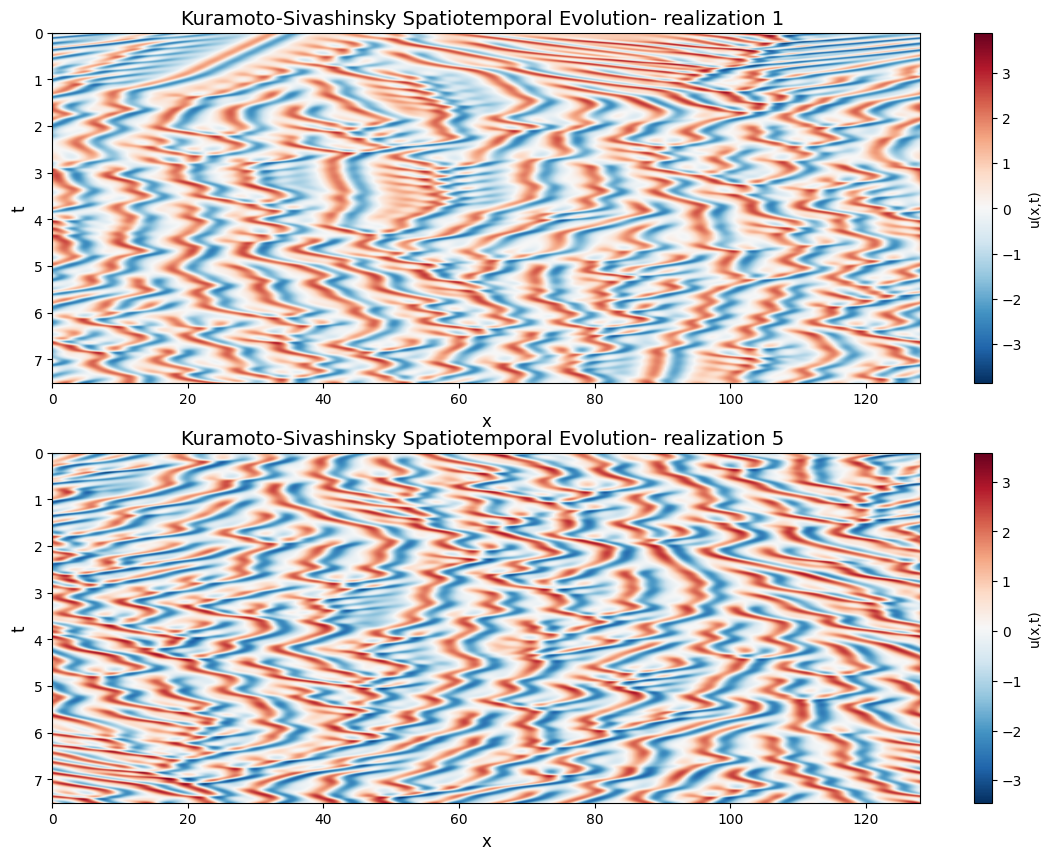

In [3]:
# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for i in range(2):
    # Spacetime plot
    im = axes[i].imshow(trajectories[i*4+1], aspect='auto', extent=[0, Lx, t[-1], t[0]], 
                cmap='RdBu_r', interpolation='bilinear')
    axes[i].set_xlabel('x', fontsize=12)
    axes[i].set_ylabel('t', fontsize=12)
    axes[i].set_title(f'Kuramoto-Sivashinsky Spatiotemporal Evolution- realization {4*i+1} ', fontsize=14)
    plt.colorbar(im, ax=axes[i], label='u(x,t)')

## Constructing the Training Dataset

### Training Data Structure

Now that we have multiple trajectories, we construct a **supervised learning dataset** for time series prediction. The goal is to train a model that can predict the flow field at the next time step from the current state.

### Data Construction Method

For each trajectory, we create training examples using a **single time step prediction**:

#### Input-Output Pairs

We create pairs of **consecutive time steps**:

$$\text{Input: } \mathbf{X} = u(x, t)$$
$$\text{Output: } \mathbf{y} = u(x, t+\Delta t)$$

The model learns the mapping: **current spatial field → next spatial field**

This is equivalent to learning the **time evolution operator** or **flow map** of the system.

### Implementation
```python
X_train = []  # Input: current states
y_train = []  # Output: next states

for trajectory in all_trajectories:
    n_timesteps = trajectory.shape[0]
    
    for t in range(n_timesteps - 1):
        # Input: spatial field at time t
        X_train.append(trajectory[t, :])
        
        # Output: spatial field at time t+dt
        y_train.append(trajectory[t+1, :])

X_train = np.array(X_train)  # Shape: (n_samples, n_spatial)
y_train = np.array(y_train)  # Shape: (n_samples, n_spatial)
```

### Dataset Dimensions

Given our dataset with shape `(n_trajectories, n_timesteps, n_spatial)`:

**Training inputs:**
- Shape: `(n_samples, n_spatial)`
- Where: `n_samples = n_trajectories × (n_timesteps - 1)`

**Training outputs:**
- Shape: `(n_samples, n_spatial)`

**Example**: 
- 10 trajectories, 201 time steps each, 1024 spatial points
- Results in: `(10 × 200, 1024)` = `(2000, 1024)` samples
- Each sample is a pair: spatial field → next spatial field

### Physical Interpretation

This formulation treats the problem as learning the **discrete-time dynamical system**:

$$u^{n+1} = \mathcal{F}(u^n)$$

where:
- $u^n = u(x, t_n)$ is the spatial field at time $t_n$
- $\mathcal{F}$ is the time evolution operator (what our neural network learns)
- The true operator is defined by the KS equation integrated over $\Delta t$

### Multi-Step Prediction

Once trained, we can use the model for **iterative prediction** over multiple time steps:
```python
# Start from an initial condition
u_current = u_initial

predictions = [u_current]

# Predict T steps into the future
for _ in range(T):
    u_next = model.predict(u_current)
    predictions.append(u_next)
    u_current = u_next  # Feed prediction as next input
```

**Note**: Due to chaos, prediction accuracy will degrade over time. The **prediction horizon** is limited by the system's Lyapunov time.

### Data Splitting

Split the dataset into train/validation/test sets:

#### Option 1: Random splitting across all samples
```python
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
```

#### Option 2: Hold out entire trajectories (recommended)
```python
# Training: trajectories 0-6 (7 trajectories)
# Validation: trajectories 7-8 (2 trajectories)  
# Testing: trajectory 9 (1 trajectory)

train_trajs = all_trajectories[:7]
val_trajs = all_trajectories[7:9]
test_trajs = all_trajectories[9:]

# Then construct X, y pairs for each split
```

**Why hold out entire trajectories?**
- Tests generalization to completely unseen chaotic realizations
- More realistic evaluation of model performance
- Avoids temporal leakage between train/test sets

### Advantages of This Formulation

1. **Simplicity**: Direct one-to-one mapping, easier to train
2. **Spatial learning**: Model focuses on learning spatial patterns and their evolution
3. **Flexible architectures**: Works with CNNs, MLPs, autoencoders, or FNOs
4. **Physical interpretation**: Directly approximates the flow map
5. **Maximum data efficiency**: Creates `O(n_trajectories × n_timesteps)` training samples

### Next Steps

With this training data, we can train an ML tool to predict the system at multiple horizontal resolution:

- **Original resolution**: n_spatial --> 512 
- **Lower resolutions**: n_spatial/4, n_spatial/8, ..., n_spatial sampled randomly from the original 512 grids. 



---

CONSTRUCTING TRAINING DATA FROM KS TRAJECTORIES

Generating 256 trajectories...
  Trajectory 1/256 complete, shape: (801, 512)
  Trajectory 2/256 complete, shape: (801, 512)
  Trajectory 3/256 complete, shape: (801, 512)
  Trajectory 4/256 complete, shape: (801, 512)
  Trajectory 5/256 complete, shape: (801, 512)
  Trajectory 6/256 complete, shape: (801, 512)
  Trajectory 7/256 complete, shape: (801, 512)
  Trajectory 8/256 complete, shape: (801, 512)
  Trajectory 9/256 complete, shape: (801, 512)
  Trajectory 10/256 complete, shape: (801, 512)
  Trajectory 11/256 complete, shape: (801, 512)
  Trajectory 12/256 complete, shape: (801, 512)
  Trajectory 13/256 complete, shape: (801, 512)
  Trajectory 14/256 complete, shape: (801, 512)
  Trajectory 15/256 complete, shape: (801, 512)
  Trajectory 16/256 complete, shape: (801, 512)
  Trajectory 17/256 complete, shape: (801, 512)
  Trajectory 18/256 complete, shape: (801, 512)
  Trajectory 19/256 complete, shape: (801, 512)
  Trajectory 20/2

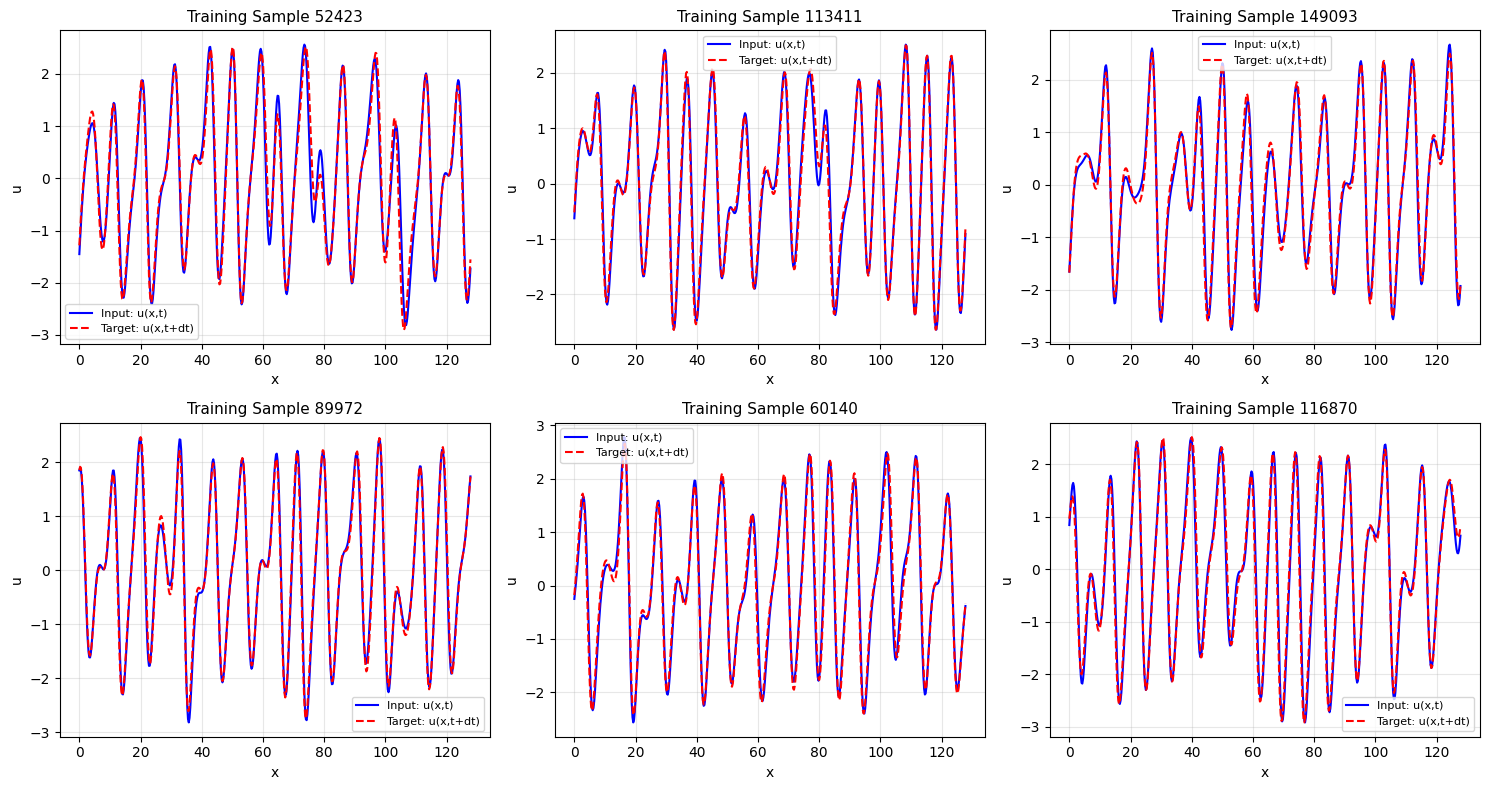


TRAINING DATA STATISTICS

Training Set:
  Samples: 163840
  Input (X) - mean: -0.000000, std: 1.313306
  Input (X) - min: -5.278669, max: 5.331238
  Output (y) - mean: -0.000000, std: 1.313397
  Output (y) - min: -5.278669, max: 5.331238

Validation Set:
  Samples: 20480
  Input (X) - mean: -0.000000, std: 1.312980
  Input (X) - min: -5.035934, max: 4.876803
  Output (y) - mean: 0.000000, std: 1.312961
  Output (y) - min: -4.616739, max: 4.993280

Test Set:
  Samples: 20480
  Input (X) - mean: 0.000000, std: 1.312284
  Input (X) - min: -4.704273, max: 4.849379
  Output (y) - mean: -0.000000, std: 1.312430
  Output (y) - min: -4.704273, max: 4.671644

Temporal Differences (y - X):
  Training - mean: 0.000000, std: 0.234142
  Validation - mean: 0.000000, std: 0.235745
  Test - mean: -0.000000, std: 0.234129

Saved: temporal_differences.png


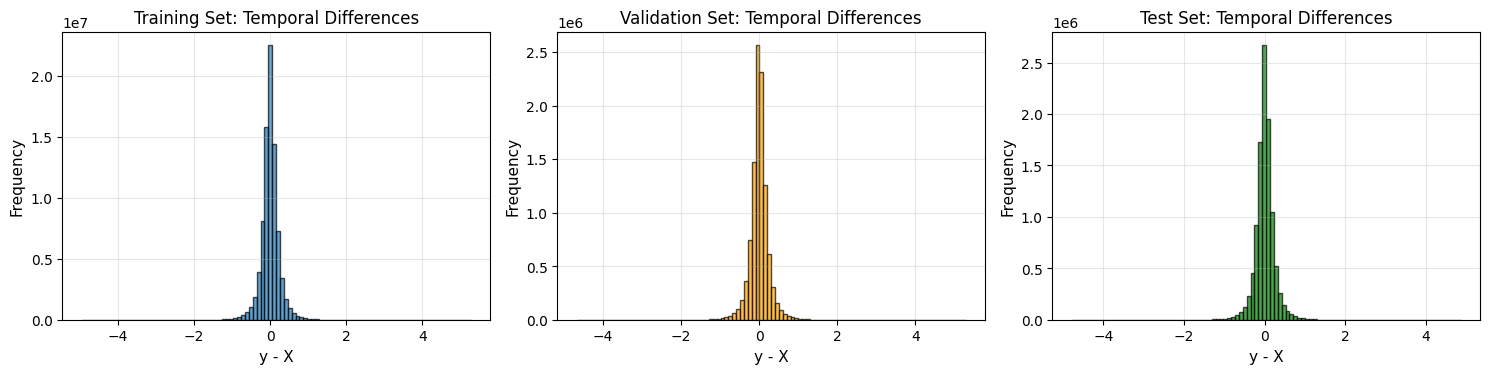


METHOD 2: Split by Entire Trajectories (Recommended)

Input trajectories shape: (256, 801, 512)
  256 trajectories
  801 time steps per trajectory
  512 spatial points per time step

Total samples created: 204800
X shape: (204800, 512) (n_samples, n_spatial)
y shape: (204800, 512) (n_samples, n_spatial)

Splitting method: Hold out entire trajectories
  Training trajectories: 179
  Validation trajectories: 38
  Test trajectories: 39

Training set:   143200 samples from 179 trajectories
Validation set: 30400 samples from 38 trajectories
Test set:       31200 samples from 39 trajectories

✓ Saved trajectory-split data:
  X_train_traj_split.npy, y_train_traj_split.npy
  X_val_traj_split.npy, y_val_traj_split.npy
  X_test_traj_split.npy, y_test_traj_split.npy

TRAINING DATA STATISTICS

Training Set:
  Samples: 143200
  Input (X) - mean: -0.000000, std: 1.312632
  Input (X) - min: -5.035934, max: 5.115631
  Output (y) - mean: -0.000000, std: 1.312717
  Output (y) - min: -5.035934, max: 5.11

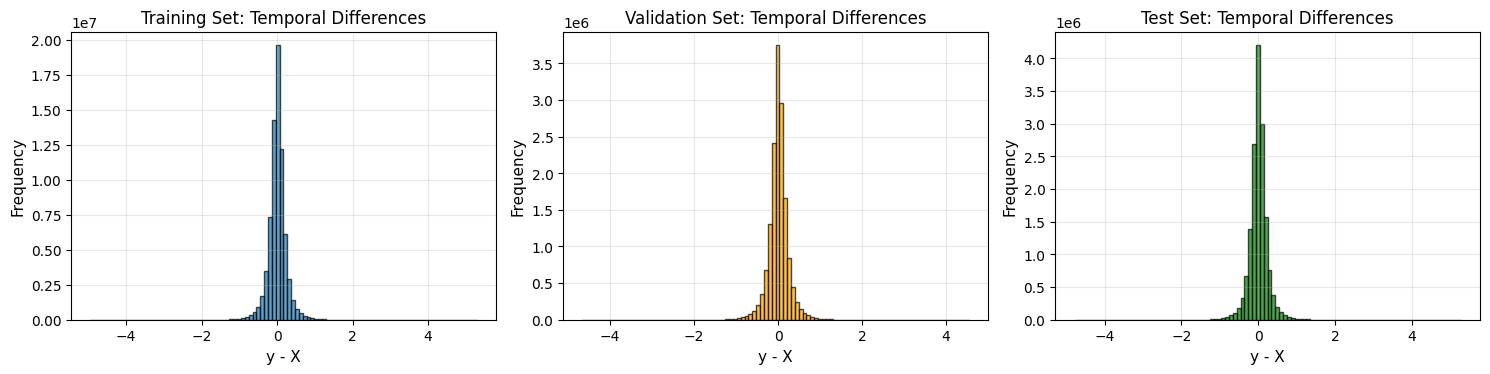


TRAINING DATA CONSTRUCTION COMPLETE!

Next steps:
  1. Load data: X_train = np.load('X_train.npy')
  2. Normalize if needed: (X - mean) / std
  3. Train your neural network model
  4. Evaluate on validation set
  5. Test on held-out test set


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def construct_training_data(trajectories, method='all_samples'):
    """
    Construct training data from multiple KS trajectories.
    
    Parameters:
    -----------
    trajectories : array of shape (n_trajectories, n_timesteps, n_spatial)
        Multiple KS trajectories
    method : str
        'all_samples': Create X,y pairs from all trajectories combined
        'split_trajectories': Split by entire trajectories
    
    Returns:
    --------
    X_train, y_train : arrays
        Training input-output pairs
    X_val, y_val : arrays (if method='all_samples')
        Validation pairs
    X_test, y_test : arrays (if method='all_samples')
        Test pairs
    """
    n_trajectories, n_timesteps, n_spatial = trajectories.shape
    
    print(f"Input trajectories shape: {trajectories.shape}")
    print(f"  {n_trajectories} trajectories")
    print(f"  {n_timesteps} time steps per trajectory")
    print(f"  {n_spatial} spatial points per time step")
    print()
    
    # Construct input-output pairs
    X = []
    y = []
    
    for traj_idx in range(n_trajectories):
        trajectory = trajectories[traj_idx]
        
        for t in range(n_timesteps - 1):
            # Input: spatial field at time t
            X.append(trajectory[t, :])
            
            # Output: spatial field at time t+1
            y.append(trajectory[t+1, :])
    
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    
    print(f"Total samples created: {len(X)}")
    print(f"X shape: {X.shape} (n_samples, n_spatial)")
    print(f"y shape: {y.shape} (n_samples, n_spatial)")
    print()
    
    if method == 'all_samples':
        # Random split across all samples
        print("Splitting method: Random split across all samples")
        print("  80% train, 10% validation, 10% test")
        
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
        )
        
        print(f"\nTraining set:   {X_train.shape[0]} samples")
        print(f"Validation set: {X_val.shape[0]} samples")
        print(f"Test set:       {X_test.shape[0]} samples")
        
        return X_train, y_train, X_val, y_val, X_test, y_test
    
    elif method == 'split_trajectories':
        # Split by entire trajectories
        print("Splitting method: Hold out entire trajectories")
        
        n_train = int(0.7 * n_trajectories)
        n_val = int(0.15 * n_trajectories)
        
        # Ensure at least 1 trajectory for val and test
        if n_val == 0:
            n_val = 1
        n_test = n_trajectories - n_train - n_val
        if n_test == 0:
            n_test = 1
            n_train = n_trajectories - n_val - n_test
        
        print(f"  Training trajectories: {n_train}")
        print(f"  Validation trajectories: {n_val}")
        print(f"  Test trajectories: {n_test}")
        
        train_trajs = trajectories[:n_train]
        val_trajs = trajectories[n_train:n_train+n_val]
        test_trajs = trajectories[n_train+n_val:]
        
        # Construct X, y for each split
        X_train, y_train = [], []
        for traj in train_trajs:
            for t in range(len(traj) - 1):
                X_train.append(traj[t, :])
                y_train.append(traj[t+1, :])
        
        X_val, y_val = [], []
        for traj in val_trajs:
            for t in range(len(traj) - 1):
                X_val.append(traj[t, :])
                y_val.append(traj[t+1, :])
        
        X_test, y_test = [], []
        for traj in test_trajs:
            for t in range(len(traj) - 1):
                X_test.append(traj[t, :])
                y_test.append(traj[t+1, :])
        
        X_train, y_train = np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32)
        X_val, y_val = np.array(X_val, dtype=np.float32), np.array(y_val, dtype=np.float32)
        X_test, y_test = np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32)
        
        print(f"\nTraining set:   {X_train.shape[0]} samples from {n_train} trajectories")
        print(f"Validation set: {X_val.shape[0]} samples from {n_val} trajectories")
        print(f"Test set:       {X_test.shape[0]} samples from {n_test} trajectories")
        
        return X_train, y_train, X_val, y_val, X_test, y_test


def visualize_training_samples(X_train, y_train, x_grid, n_samples=6):
    """
    Visualize some training examples
    """
    indices = np.random.choice(len(X_train), n_samples, replace=False)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        axes[i].plot(x_grid, X_train[idx], 'b-', linewidth=1.5, label='Input: u(x,t)')
        axes[i].plot(x_grid, y_train[idx], 'r--', linewidth=1.5, label='Target: u(x,t+dt)')
        axes[i].set_xlabel('x', fontsize=10)
        axes[i].set_ylabel('u', fontsize=10)
        axes[i].set_title(f'Training Sample {idx}', fontsize=11)
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_samples.png', dpi=150, bbox_inches='tight')
    print("Saved: training_samples.png")
    plt.show()


def analyze_training_data(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Analyze the training data statistics
    """
    print("\n" + "="*60)
    print("TRAINING DATA STATISTICS")
    print("="*60)
    
    datasets = [
        ('Training', X_train, y_train),
        ('Validation', X_val, y_val),
        ('Test', X_test, y_test)
    ]
    
    for name, X, y in datasets:
        print(f"\n{name} Set:")
        print(f"  Samples: {len(X)}")
        print(f"  Input (X) - mean: {X.mean():.6f}, std: {X.std():.6f}")
        print(f"  Input (X) - min: {X.min():.6f}, max: {X.max():.6f}")
        print(f"  Output (y) - mean: {y.mean():.6f}, std: {y.std():.6f}")
        print(f"  Output (y) - min: {y.min():.6f}, max: {y.max():.6f}")
    
    # Compute temporal difference statistics
    print(f"\nTemporal Differences (y - X):")
    diff_train = y_train - X_train
    diff_val = y_val - X_val
    diff_test = y_test - X_test
    
    print(f"  Training - mean: {diff_train.mean():.6f}, std: {diff_train.std():.6f}")
    print(f"  Validation - mean: {diff_val.mean():.6f}, std: {diff_val.std():.6f}")
    print(f"  Test - mean: {diff_test.mean():.6f}, std: {diff_test.std():.6f}")
    
    # Plot difference distribution
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].hist(diff_train.flatten(), bins=100, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('y - X', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Training Set: Temporal Differences', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(diff_val.flatten(), bins=100, alpha=0.7, color='orange', edgecolor='black')
    axes[1].set_xlabel('y - X', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Validation Set: Temporal Differences', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    axes[2].hist(diff_test.flatten(), bins=100, alpha=0.7, color='green', edgecolor='black')
    axes[2].set_xlabel('y - X', fontsize=11)
    axes[2].set_ylabel('Frequency', fontsize=11)
    axes[2].set_title('Test Set: Temporal Differences', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('temporal_differences.png', dpi=150, bbox_inches='tight')
    print("\nSaved: temporal_differences.png")
    plt.show()


# Main execution
if __name__ == "__main__":
    print("="*60)
    print("CONSTRUCTING TRAINING DATA FROM KS TRAJECTORIES")
    print("="*60)
    print()
    
   
   
    # Generate multiple trajectories for robust training
    trajectories, x_grid, t_grid = generate_multiple_trajectories(
        n_trajectories=256, # number of trajectories # in case you need more samples change this to a larger value
        Lx=128,  # domain length
        Nx=512, # spatial grid points
        dt=1/32, #  time step
        Nt=16000, # total time steps # in case you need more samples change this to a larger value
        nplot=20, # save every nplot time steps
        nspin_up=1000 # number of initial steps to skip for spin-up
    )
    print("\n" + "="*60)
    print("METHOD 1: Random Split Across All Samples")
    print("="*60 + "\n")
    trajectories = np.stack(trajectories).astype(np.float32)

    X_train, y_train, X_val, y_val, X_test, y_test = construct_training_data(
        trajectories, method='all_samples'
    )
    
    # Save the data
    np.save('X_train.npy', X_train)
    np.save('y_train.npy', y_train)
    np.save('X_val.npy', X_val)
    np.save('y_val.npy', y_val)
    np.save('X_test.npy', X_test)
    np.save('y_test.npy', y_test)
    
    print("\n✓ Saved training data:")
    print("  X_train.npy, y_train.npy")
    print("  X_val.npy, y_val.npy")
    print("  X_test.npy, y_test.npy")
    
    # Visualize some samples
    print("\nVisualizing training samples...")
    visualize_training_samples(X_train, y_train, x_grid, n_samples=6)
    
    # Analyze the data
    analyze_training_data(X_train, y_train, X_val, y_val, X_test, y_test)
    
    print("\n" + "="*60)
    print("METHOD 2: Split by Entire Trajectories (Recommended)")
    print("="*60 + "\n")
    
    X_train2, y_train2, X_val2, y_val2, X_test2, y_test2 = construct_training_data(
        trajectories, method='split_trajectories'
    )
    
    # # Save the data with different names
    # np.save('X_train_traj_split.npy', X_train2)
    # np.save('y_train_traj_split.npy', y_train2)
    # np.save('X_val_traj_split.npy', X_val2)
    # np.save('y_val_traj_split.npy', y_val2)
    # np.save('X_test_traj_split.npy', X_test2)
    # np.save('y_test_traj_split.npy', y_test2)
    
    print("\n✓ Saved trajectory-split data:")
    print("  X_train_traj_split.npy, y_train_traj_split.npy")
    print("  X_val_traj_split.npy, y_val_traj_split.npy")
    print("  X_test_traj_split.npy, y_test_traj_split.npy")
    
    # Analyze
    analyze_training_data(X_train2, y_train2, X_val2, y_val2, X_test2, y_test2)
    
    print("\n" + "="*60)
    print("TRAINING DATA CONSTRUCTION COMPLETE!")
    print("="*60)
    print("\nNext steps:")
    print("  1. Load data: X_train = np.load('X_train.npy')")
    print("  2. Normalize if needed: (X - mean) / std")
    print("  3. Train your neural network model")
    print("  4. Evaluate on validation set")
    print("  5. Test on held-out test set")
    print("="*60)

In [5]:
# import numpy as np
# from pathlib import Path

# # Where Project2 expects the data
# SAVE_DIR = Path("/scratch/pp3051/weather")
# SAVE_DIR.mkdir(parents=True, exist_ok=True)

# # === CONFIG: how big you want your dataset ===
# N_REAL = 64        # number of different random realizations
# T_MAX  = 400       # number of time steps to save per realization (after any burn-in)
# SEED   = 1337      # base random seed

# # Use the same dt, Lx, Nx, etc. as in the rest of the notebook
# dt = 0.25          # <- set to the dt you actually use in this notebook
# Lx = 128.0         # <- or whatever domain length you used
# Nx = 512           # <- spatial grid size

# # If you already have a spatial grid "x" defined earlier, reuse it. Otherwise:
# x_grid = (np.arange(Nx, dtype=np.float64) + 0.5) * (Lx / Nx)


# def make_random_ic(N, Lx, rng):
#     """
#     Generate a random initial condition u0(x).
#     Replace this with exactly how your professor defines ICs in the notebook.
#     This is just a reasonable default: low-frequency smooth noise.
#     """
#     # Example: smooth random IC via truncated Fourier series
#     kmax = 8
#     ks = 2.0 * np.pi * np.fft.fftfreq(N, d=Lx/N)
#     u_hat = np.zeros(N, dtype=np.complex128)
#     for _ in range(kmax):
#         k = rng.integers(1, N//4)
#         phase = rng.uniform(0, 2*np.pi)
#         amp = rng.normal(0, 0.5)
#         u_hat[k] = amp * np.exp(1j * phase)
#         u_hat[-k] = amp * np.exp(-1j * phase)
#     u0 = np.fft.ifft(u_hat).real
#     return u0.astype(np.float64)


# def make_ks_etdrk4_step(Nx, Lx, dt):
#     """
#     Build a one-step ETDRK4 integrator for KS on a periodic domain [0, Lx).
#     KS in standard non-dimensional form:
#         u_t = -u*u_x - u_xx - u_xxxx
#     """
#     k = 2.0 * np.pi * np.fft.fftfreq(Nx, d=Lx / Nx)
#     ik = 1j * k

#     # Linear part: L = k^2 - k^4 corresponds to u_t = -u*u_x - u_xx - u_xxxx
#     L = k**2 - k**4

#     E  = np.exp(L * dt)
#     E2 = np.exp(L * dt / 2.0)

#     M  = 16
#     r  = np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)
#     LR = dt * L[:, None] + r[None, :]

#     Q  = dt * np.real(np.mean((np.exp(LR/2.0) - 1.0) / LR, axis=1))
#     f1 = dt * np.real(np.mean((-4.0 - LR + np.exp(LR)*(4.0 - 3.0*LR + LR**2)) / LR**3, axis=1))
#     f2 = dt * np.real(np.mean(( 2.0 + LR + np.exp(LR)*(-2.0 + LR)) / LR**3, axis=1))
#     f3 = dt * np.real(np.mean((-4.0 - 3.0*LR - LR**2 + np.exp(LR)*(4.0 - LR)) / LR**3, axis=1))

#     def step(u):
#         # u: [Nx], real
#         u_hat = np.fft.fft(u)
#         # Nonlinear term N(u) = -u*u_x  => in Fourier: -0.5 * ik * FFT(u^2)
#         N1 = -0.5 * ik * np.fft.fft(np.real(np.fft.ifft(u_hat))**2)
#         a  = E2 * u_hat + Q * N1

#         N2 = -0.5 * ik * np.fft.fft(np.real(np.fft.ifft(a))**2)
#         b  = E2 * u_hat + Q * N2

#         N3 = -0.5 * ik * np.fft.fft(np.real(np.fft.ifft(b))**2)
#         c  = E2 * a + Q * (2.0 * N3 - N1)

#         N4 = -0.5 * ik * np.fft.fft(np.real(np.fft.ifft(c))**2)

#         u_hat_next = (
#             E * u_hat
#             + N1 * f1
#             + 2.0 * (N2 + N3) * f2
#             + N4 * f3
#         )
#         u_next = np.real(np.fft.ifft(u_hat_next))
#         return u_next

#     return step


# def integrate_ks_one_realization(u0, dt, T_max):
#     """
#     Run the KS solver for a single realization starting from u0
#     using an ETDRK4 time integrator.
#     Returns:
#       traj: (T_max, Nx)
#       t:    (T_max,)
#     """
#     u = u0.copy()
#     traj = np.zeros((T_max, Nx), dtype=np.float64)
#     t = np.zeros(T_max, dtype=np.float64)

#     ks_step = make_ks_etdrk4_step(Nx, Lx, dt)

#     for n in range(T_max):
#         traj[n] = u
#         t[n] = n * dt
#         u = ks_step(u)

#     return traj, t


# # ===========================
# # Generate the big ks_data
# # ===========================

# rng = np.random.default_rng(SEED)
# all_trajs = []

# for r in range(N_REAL):
#     print(f"[ks_data] realization {r+1}/{N_REAL}")

#     # 1) Initial condition (replace with your professor's IC logic if needed)
#     u0 = make_random_ic(Nx, Lx, rng)

#     # 2) Integrate KS forward in time
#     u_traj, t_arr = integrate_ks_one_realization(u0, dt=dt, T_max=T_MAX)

#     all_trajs.append(u_traj)

# ks_data = np.stack(all_trajs, axis=0)  # [N_REAL, T_MAX, Nx]

# # ===========================
# # Save for Project2
# # ===========================
# np.save(SAVE_DIR / "ks_data1.npy", ks_data.astype(np.float32))
# np.save(SAVE_DIR / "ks_time1.npy", t_arr.astype(np.float32))
# np.save(SAVE_DIR / "ks_spatial_grid1.npy", x_grid.astype(np.float32))

# print(f"[done] ks_data1.npy shape {ks_data.shape} saved to {SAVE_DIR}")
# print(f"[done] ks_time1.npy shape {t_arr.shape}")
# print(f"[done] ks_spatial_grid1.npy shape {x_grid.shape}")
